In [1]:
# =================================
# 設定
# =================================
IS_ONLINE_JUDGE = False

LIMIT_QUERY_CNT = None

DEBUG = False
DEBUG_QUERY = None
DEBUG_L = None

MAX_TIME = 1.25
FILE_NUM = 100

# =================================
# 初期化
# =================================
import time

GLOBAL_START_TIME = time.perf_counter()

import random

random.seed(1111)

import sys

sys.setrecursionlimit(10**9)
if IS_ONLINE_JUDGE:
    DEBUG = False

# =================================
# Import
# =================================
from collections import defaultdict, deque

# =================================
# 共通
# =================================
if True:
    from importlib import reload

    import src.common as common

    reload(common)


from src.common import (
    Env,
    EnvOffline,
    UnionFind,
    calc_dist,
    calc_rectangle_dist_min_max,
    construct_dag_and_rdag_from_edges,
    construct_dag_from_edges,
    construct_dist_matrix,
    construct_dist_matrix_rectangle,
    construct_graph,
    construct_graph_from_edges,
    construct_graph_from_list,
    construct_sorted_edges,
    cut_graph,
    divide_interval,
    exponential_schedule,
    is_overlap,
    kruskals_algorithm,
    linear_schedule,
    my_deepcopy,
    prim,
    prim_k,
    prim_vs,
    priority_topological_sort,
    scc,
    scc_construct,
    sort_pair,
)


# =================================
# 汎用（main.py専用）
# =================================
def debug_print(*args, **kwargs):
    if IS_ONLINE_JUDGE:
        return
    print(*args, **kwargs)


def print_elapsed_time():
    debug_print(f"elapsed time: {(time.perf_counter() - GLOBAL_START_TIME) * 1000:.2f}msecs")

In [23]:
from numba import njit
from numba.pycc import CC

cc = CC("my_module")


@cc.export("square", "f8(f8)")
def square(a):
    return a**2


if __name__ == "__main__":
    st = time.perf_counter()
    cc.compile()
    et = time.perf_counter()
    print("elapsed time:", et - st)

elapsed time: 1.7497857440030202


In [21]:
def my_square(a):
    return a**2

In [22]:
import time

st = time.perf_counter()
for _ in range(10**8):
    square(99.9)
et = time.perf_counter()
print("elapsed time:", et - st)

st = time.perf_counter()
for _ in range(10**8):
    my_square(99.9)
et = time.perf_counter()
print("elapsed time:", et - st)

elapsed time: 7.246551568998257
elapsed time: 6.898496070993133


In [2]:
file_num = 62
input_file_path = f"../in/{file_num:04d}.txt"
output_file_path = f"../out/{file_num:04d}.txt"
env = EnvOffline(input_file_path, output_file_path)

In [3]:
edgeid_to_poinid = {}
pointid_to_edgeid = {}
edge_id = 0
for v in range(env.N):
    for j in range(v + 1, env.N):
        edgeid_to_poinid[edge_id] = (v, j)
        pointid_to_edgeid[(v, j)] = edge_id
        edge_id += 1

# correct_edge_dists = calc_edge_list(env, env.coordinates)
# estimate_edge_dists = calc_edge_list(env, env.cneter_points)

# correct_ranks = [v[1] for v in correct_edge_dists]
# estimate_ranks = [v[1] for v in estimate_edge_dists]

# EDGE_NUM = len(estimate_ranks)

In [13]:
all_graph = construct_graph({i: p for i, p in enumerate(env.cneter_points)})

constrains = set()
random_vs = []

for _ in range(200):
    point_ids = list(range(env.N))
    random_v = random.sample(point_ids, k=1)[0]
    other_points = all_graph[random_v][:50]
    other_points = random.sample([p for d, p in other_points], k=14)

    tmp_random_vs = [random_v] + other_points

    edges = env.query(tmp_random_vs)
    graph = construct_graph_from_edges(edges, tmp_random_vs)

    for e in edges:
        e1_id = pointid_to_edgeid[e]
        group_vs1, group_vs2 = cut_graph(graph, e)
        for v1 in group_vs1:
            for v2 in group_vs2:
                sv1, sv2 = sort_pair((v1, v2))
                if e == (sv1, sv2):
                    continue
                e2_id = pointid_to_edgeid[(sv1, sv2)]
                constrains.add((e1_id, e2_id))

                if DEBUG:
                    long_c1 = env.coordinates[sv1]
                    long_c2 = env.coordinates[sv2]
                    short_c1 = env.coordinates[e[0]]
                    short_c2 = env.coordinates[e[1]]
                    dist1 = calc_dist(short_c1, short_c2)
                    dist2 = calc_dist(long_c1, long_c2)
                    if dist1 > dist2:
                        debug_print((dist1, dist2), e, (sv1, sv2), e1_id, e2_id)
                    assert dist1 <= dist2
    random_vs.extend(tmp_random_vs)

In [17]:
len(constrains) / 250

329.124

やること

全ての制約に対して制約を満たしているかどうかの True/False リスト

tmp_update(vs: list[int, coords])


In [ ]:
def calc_cost(constrains, points):
    cost = 0
    for cons in constrains:
        e1_id, e2_id = cons
        p1 = points[edgeid_to_poinid[e1_id][0]]
        p2 = points[edgeid_to_poinid[e1_id][1]]
        q1 = points[edgeid_to_poinid[e2_id][0]]
        q2 = points[edgeid_to_poinid[e2_id][1]]
        dist1 = calc_dist(p1, p2)
        dist2 = calc_dist(q1, q2)
        if dist1 > dist2:
            cost += 1
    return cost

In [ ]:
random_points = dict()
for v in random_vs:
    x1, x2, y1, y2 = env.rectangles[v]
    random_points[v] = (random.randint(x1, x2), random.randint(y1, y2))
cost = calc_cost(constrains, random_points)
best_cost = cost
simulate_points = []
simulate_costs = []
SIMULATE_NUM = 100000
for i in range(SIMULATE_NUM):
    v = random.choice(random_vs)
    x1, x2, y1, y2 = env.rectangles[v]
    dx = x2 - x1
    dy = y2 - y1
    now_random_points = random_points.copy()
    nx, ny = now_random_points[v]

    # move_x, move_y = random.randint(-dx // 4, dx // 4), random.randint(-dy // 4, dy // 4)
    # now_random_points[v] = min(max(x1, nx + move_x), x2), min(max(y1, ny + move_y), y2)
    max_dx = max(dx // 3, 1)
    max_dy = max(dy // 3, 1)
    lim_l = max(x1, nx - max_dx)
    lim_r = min(x2, nx + max_dx)
    lim_u = max(y1, ny - max_dy)
    lim_d = min(y2, ny + max_dy)
    now_random_points[v] = random.randint(lim_l, lim_r), random.randint(lim_u, lim_d)

    now_cost = calc_cost(constrains, now_random_points)
    simulate_points.append(now_random_points)
    simulate_costs.append(now_cost)

    if now_cost < cost:
        cost = now_cost
        random_points = now_random_points
        if cost < best_cost:
            best_cost = cost
    if i % 10000 == 0:
        # キック操作
        for v in random.sample(random_vs, k=50):
            x1, x2, y1, y2 = env.rectangles[v]
            random_points[v] = (random.randint(x1, x2), random.randint(y1, y2))
        cost = calc_cost(constrains, random_points)
        # debug_print(f"[kick] i: {i}, cost: {cost}")
    if i % 200 == 0:
        debug_print(f"i: {i}, cost: {now_cost}, best_cost: {best_cost}")

i: 0, cost: 11055, best_cost: 11053
i: 200, cost: 9883, best_cost: 9883
i: 400, cost: 9046, best_cost: 9046


KeyboardInterrupt: 

In [ ]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
simulate_costs.count(0)

5353

In [ ]:
print("min_cost", min(simulate_costs))
# cost_bin = sorted(simulate_costs)[1000]
cost_bin = 0
print(cost_bin)
bin_inds = [i for i, c in enumerate(simulate_costs) if c <= cost_bin]
min_cost_points = [simulate_points[i] for i in bin_inds]

min_cost 0
0


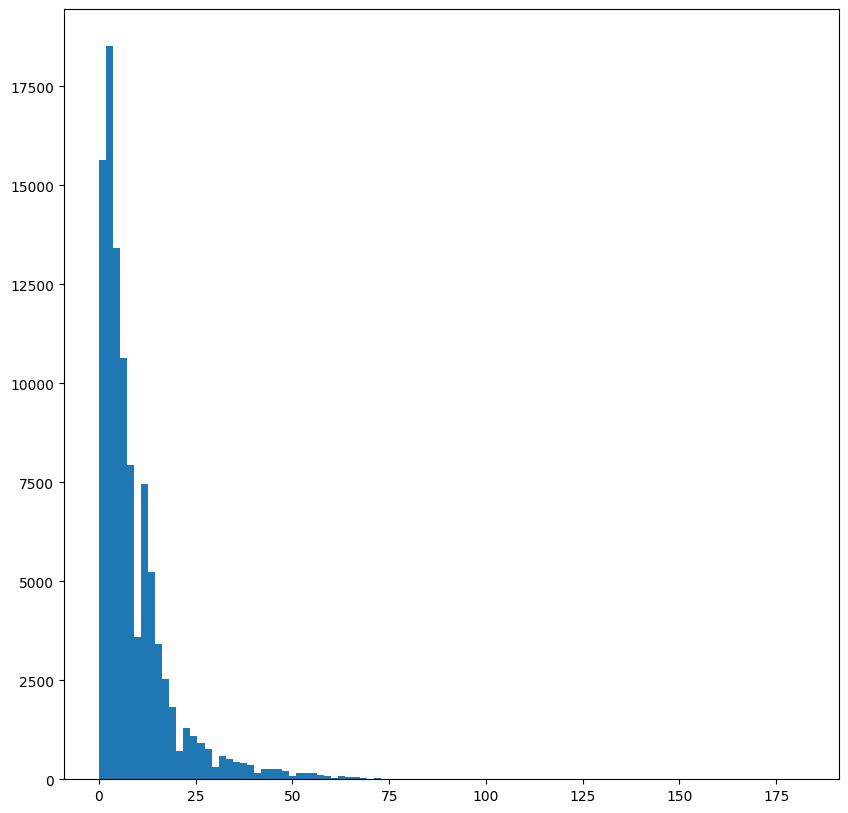

In [ ]:
plt.figure(figsize=(10, 10))
plt.hist(simulate_costs, bins=100)
plt.show()

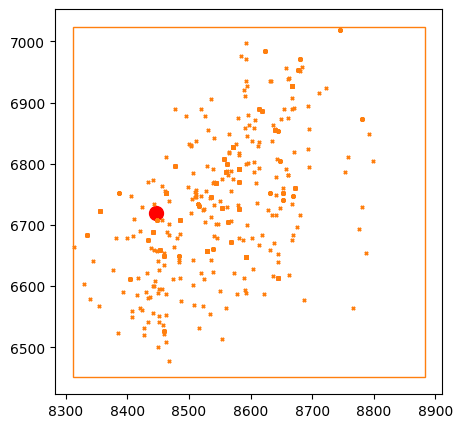

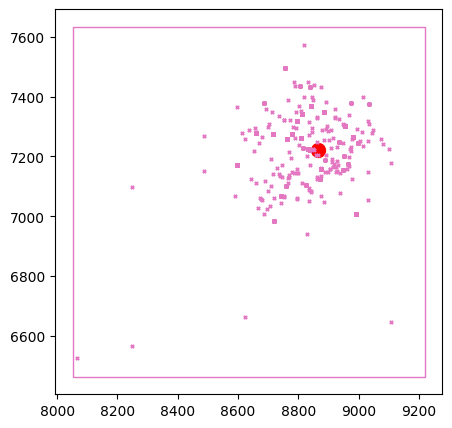

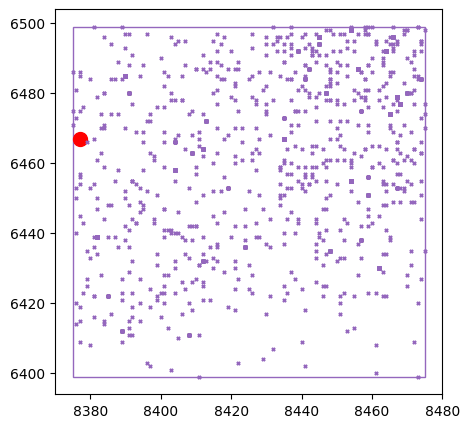

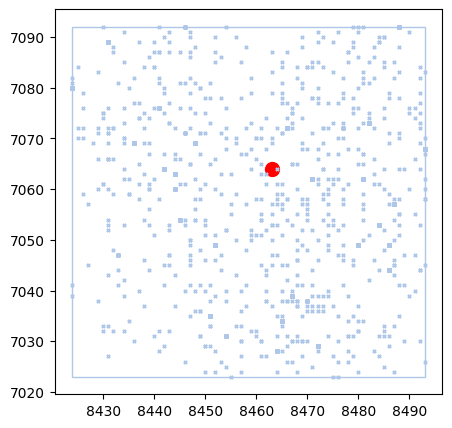

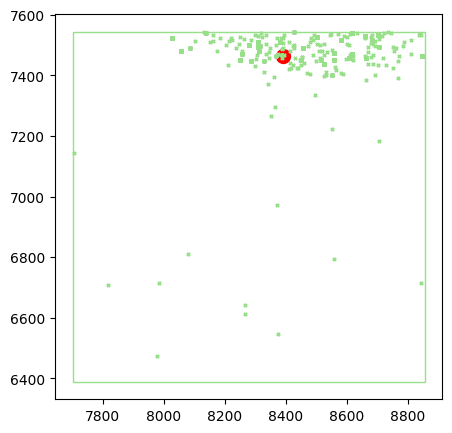

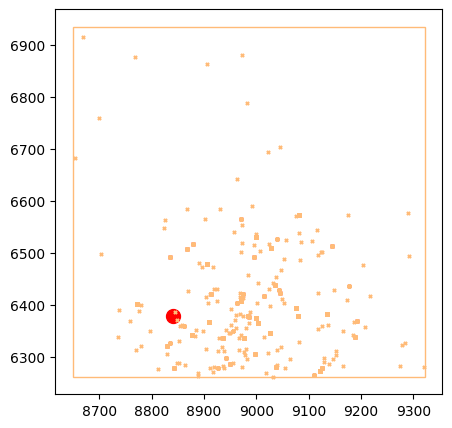

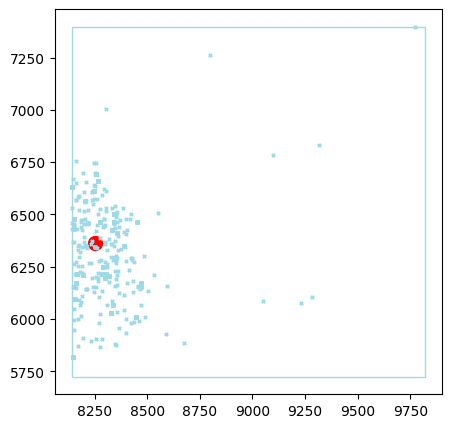

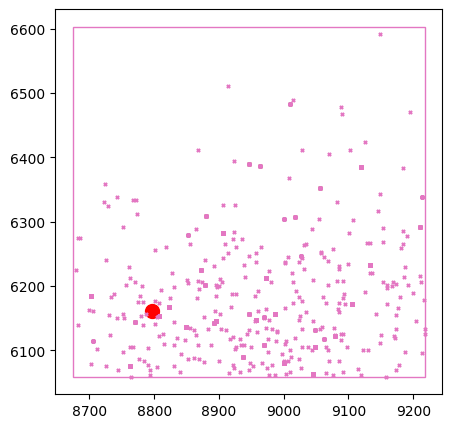

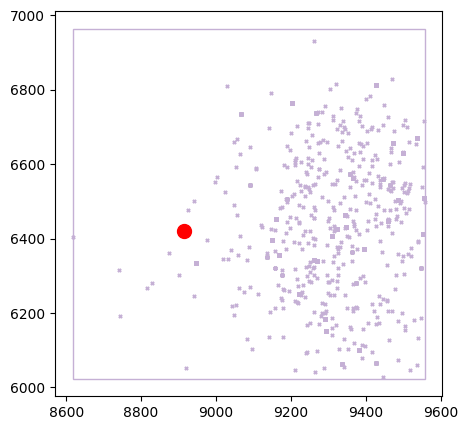

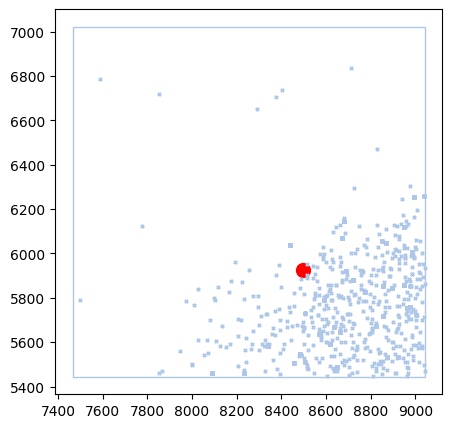

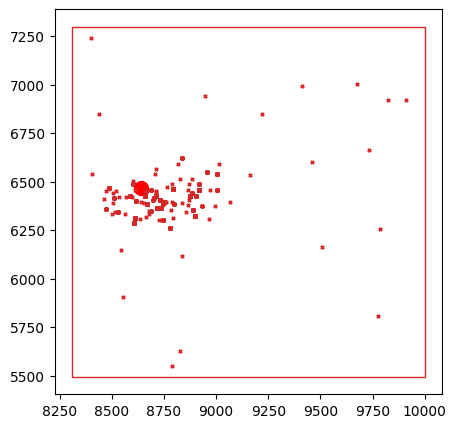

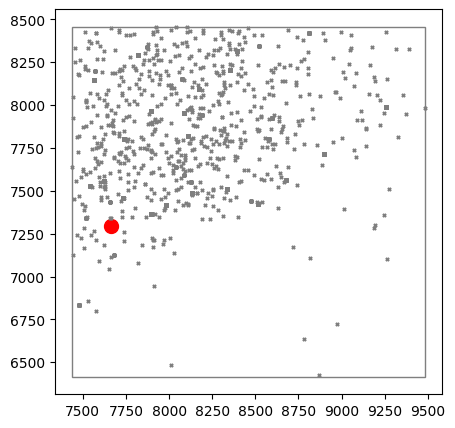

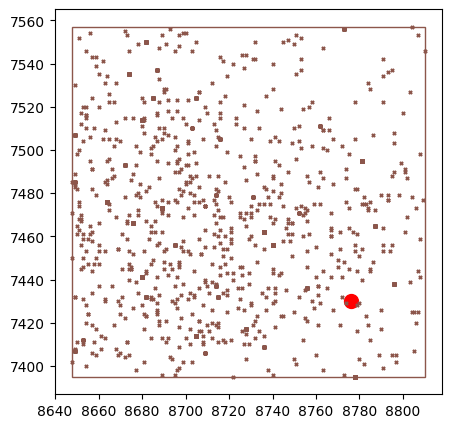

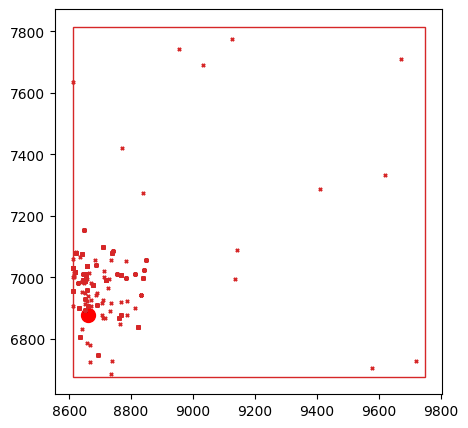

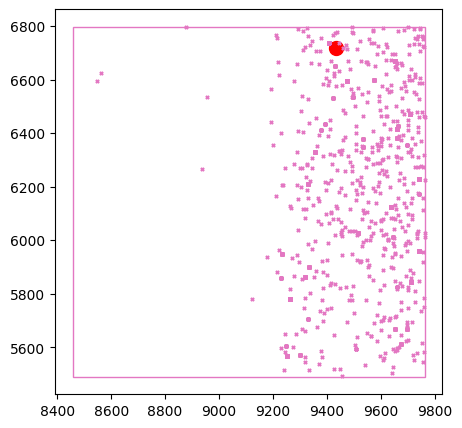

In [ ]:
def get_color(i):
    # colors = list(matplotlib.colors.CSS4_COLORS.values())
    colors = matplotlib.cm.tab20.colors
    return colors[i % len(colors)]


# corrects_np = np.array(env.coordinates)[random_vs]
# estimates_np = np.array([min_cost_points[i] for i in random_vs])
# rectangles = np.array([env.rectangles[i] for i in range(env.N)])[random_vs]

# 四角形と、四角形内の正解点と予測点を描画
# plt.figure(figsize=(10, 10))
# ax = plt.gca()
for v in random_vs:
    plt.figure(figsize=(5, 5))
    ax = plt.gca()
    color = get_color(v)
    rect = env.rectangles[v]
    l, r, t, b = rect

    ax.add_patch(matplotlib.patches.Rectangle((l, t), r - l, b - t, alpha=1, color=color, fill=False))
    p1 = env.coordinates[v]
    # p2 = estimates_np[i]
    # x = [p1[0], p2[0]]
    # y = [p1[1], p2[1]]
    # ax.plot(x, y, color=color, alpha=0.3)
    plt.scatter(p1[0], p1[1], color="red", alpha=1, label=f"correct {v}", s=100)
    x, y = [], []
    for p_list in min_cost_points:
        p2 = p_list[v]
        x.append(p2[0])
        y.append(p2[1])
    plt.scatter(x, y, color=color, alpha=1, label=f"estimate {v}", marker="x", s=5)
    plt.show()

In [ ]:
# import networkx as nx

# nx_graph = nx.Graph(graph)
# nx.draw(nx_graph, with_labels=True)


In [ ]:
# import numpy as np

# corrects = np.array([env.coordinates[i] for i in range(env.N)])
# estimates = np.array([estimate_points[i].estimate_coordinate for i in range(env.N)])
# centers = np.array([env.cneter_points[i] for i in range(env.N)])

# print("base:", calc_point_avg_distances(corrects, centers))
# print("opt", calc_point_avg_distances(corrects, estimates))

# anv_v, ans_edges = calc_greedy_answer(env, corrects)
# print("best", env.answer(anv_v, ans_edges))

# anv_v, ans_edges = update_mst(env, *calc_greedy_answer(env, estimates), define_query_cnt(env, limit_query_cnt=None))
# print("estimate", env.answer(anv_v, ans_edges))

# anv_v, ans_edges = update_mst(env, *calc_greedy_answer(env, centers), define_query_cnt(env, limit_query_cnt=None))
# print("base", env.answer(anv_v, ans_edges))

In [ ]:
# import matplotlib
# import matplotlib.pyplot as plt
# import numpy as np

# point_inds = list(range(env.N))  # longs_points[:]
# corrects_np = np.array(corrects)[point_inds]
# estimates_np = np.array(estimates)[point_inds]
# rectangles = np.array([env.rectangles[i] for i in range(env.N)])[point_inds]

# # 四角形と、四角形内の正解点と予測点を描画
# plt.figure(figsize=(10, 10))
# ax = plt.gca()
# # for i, rect in enumerate(rectangles):
# #     l, r, t, b = rect
# #     ax.add_patch(matplotlib.patches.Rectangle((l, t), r - l, b - t, alpha=0.1))
# ax.scatter(corrects_np[:, 0], corrects_np[:, 1], color="green", label="correct", s=20, marker="*")
# ax.scatter(estimates_np[:, 0], estimates_np[:, 1], color="red", label="estimate", s=5, marker="o")
# for point_ind in range(len(corrects_np)):
#     ax.plot(
#         (corrects_np[point_ind, 0], estimates_np[point_ind, 0]),
#         (corrects_np[point_ind, 1], estimates_np[point_ind, 1]),
#         color="gray",
#         label="correct path",
#     )
# plt.show()